# **1. Carga y Exploración de Datos:**



## **Cargar el dataset y revisar su estructura básica.**



In [325]:
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression,  LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from sklearn.preprocessing import StandardScaler , label_binarize


from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay, auc)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.model_selection import ( train_test_split, GridSearchCV)


df = pd.read_csv('/content/drive/MyDrive/BootCamp Skillnest-Sonda/data/WineQT.csv')

## **Exploración inicial para entender la estructura del dataset.**

In [326]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [327]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [328]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1597


In [329]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [330]:
df.shape

(1143, 13)

## **Identificar valores faltantes, duplicados**

In [331]:
# Eliminar duplicados
antes = len(df)
df.drop_duplicates(inplace=True)
print(f'Duplicados eliminados: {antes - len(df):,}')

Duplicados eliminados: 0


no tenia duplicados

## **Tratamiento de nulos**

In [332]:
#Validar Nulos
print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


El dataset viene limpio y no tiene nulos

In [333]:
# Se elimina la columna Id porque es solo un correlativo.

df = df.drop('Id', axis=1)
print('Columna "Id" eliminada.')


Columna "Id" eliminada.


## **Describir las variables y su distribución.**

In [334]:
# La variable quality es el target y su distirucion en %

print(df['quality'].value_counts().sort_index().astype(str) + '  ==>  ' + (df['quality'].value_counts(normalize=True) * 100).sort_index().round(2).astype(str) + '%')

quality
3       6  ==>  0.52%
4      33  ==>  2.89%
5    483  ==>  42.26%
6    462  ==>  40.42%
7    143  ==>  12.51%
8       16  ==>  1.4%
dtype: object


## **Identificar y tratar valores nulos y outliers.**

In [335]:
print('=' * 60)
print('Outliers - IQR)')
print('=' * 60)

features = df.columns.drop('quality')
outlier_summary = {}

for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = {
        'Q1': round(Q1, 4),
        'Q3': round(Q3, 4),
        'IQR': round(IQR, 4),
        'Límite inferior': round(lower, 4),
        'Límite superior': round(upper, 4),
        'Nº outliers': len(outliers),
        '% outliers': round(len(outliers) / len(df) * 100, 2)
    }

outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df.to_string())

Outliers - IQR)
                           Q1       Q3      IQR  Límite inferior  Límite superior  Nº outliers  % outliers
fixed acidity          7.1000   9.1000   2.0000           4.1000          12.1000         44.0        3.85
volatile acidity       0.3925   0.6400   0.2475           0.0213           1.0112         14.0        1.22
citric acid            0.0900   0.4200   0.3300          -0.4050           0.9150          1.0        0.09
residual sugar         1.9000   2.6000   0.7000           0.8500           3.6500        110.0        9.62
chlorides              0.0700   0.0900   0.0200           0.0400           0.1200         77.0        6.74
free sulfur dioxide    7.0000  21.0000  14.0000         -14.0000          42.0000         18.0        1.57
total sulfur dioxide  21.0000  61.0000  40.0000         -39.0000         121.0000         40.0        3.50
density                0.9956   0.9978   0.0023           0.9922           1.0013         36.0        3.15
pH                   

# **2. Preprocesamiento de Datos:**

## **Seleccionar características importantes para la clasificación.**

In [336]:
print('='*60)
print('Analisis de Correlacion')
print('='*60)


# Matriz de correlación con la variable target
correlations = df[feature_cols + ['quality']].corr()['quality'].sort_values(ascending=False)
print('\nCorrelación con la variable "quality":')
for var, corr in correlations.items():
    if var != 'quality':
        print(f'  {var:25s}: {corr:.2f}')

Analisis de Correlacion

Correlación con la variable "quality":
  alcohol                  : 0.48
  sulphates                : 0.26
  citric acid              : 0.24
  fixed acidity            : 0.12
  residual sugar           : 0.02
  pH                       : -0.05
  free sulfur dioxide      : -0.06
  chlorides                : -0.12
  density                  : -0.18
  total sulfur dioxide     : -0.18
  volatile acidity         : -0.41


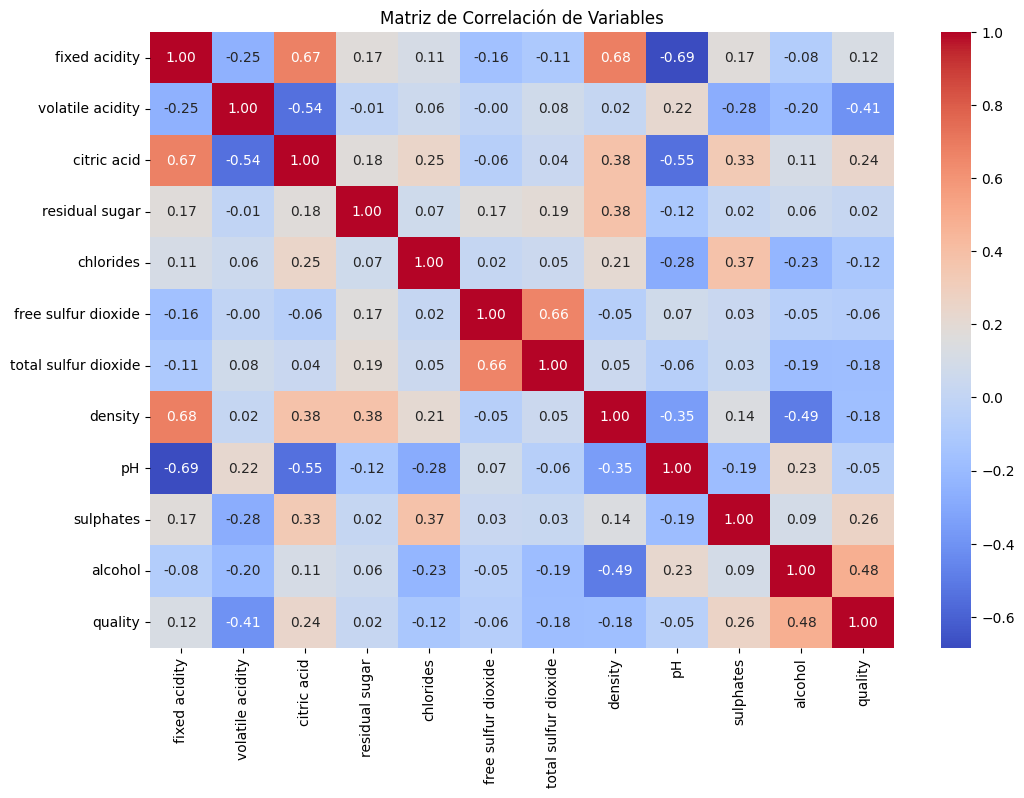

In [337]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Matriz de Correlación de Variables')
plt.show()

La matriz de correlacion confirma que la variable de alcohol y sulfatos son los componentes directo de de la calidad

# **Graficos**

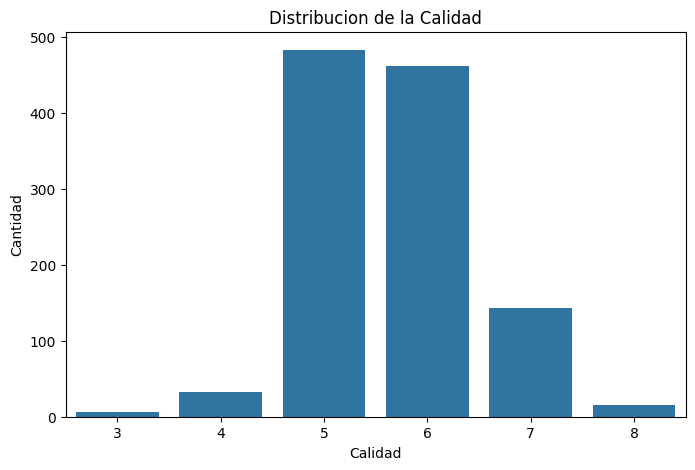

In [338]:
# Distribución Calidad

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="quality"
)

plt.title("Distribucion de la Calidad")
plt.xlabel("Calidad")
plt.ylabel("Cantidad")
plt.show()

La cantidad de muestara es de Median calidad entre los factores 5 y 6

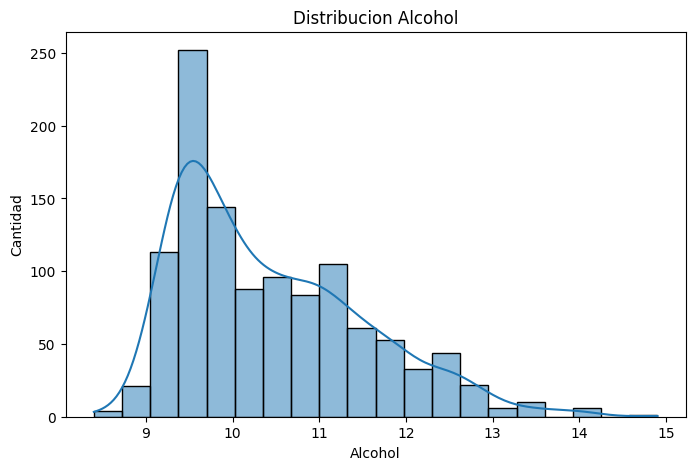

In [339]:
# Alcohol


plt.figure(figsize=(8,5))

sns.histplot(
    df["alcohol"],
    bins=20,
    kde=True
)

plt.title("Distribucion Alcohol")
plt.xlabel("Alcohol")
plt.ylabel("Cantidad")
plt.show()


La matoria de la muestra esta en tr  9 y 10  grados de alcohol

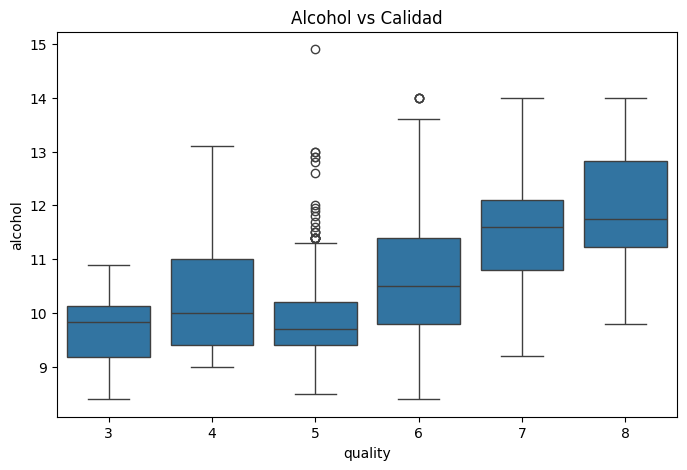

In [340]:
# Alcohol vs Calidad
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="quality",
    y="alcohol"
)

plt.title("Alcohol vs Calidad")
plt.show()

El alcohol en mayores cantidad sugiere una mejor claida de vino

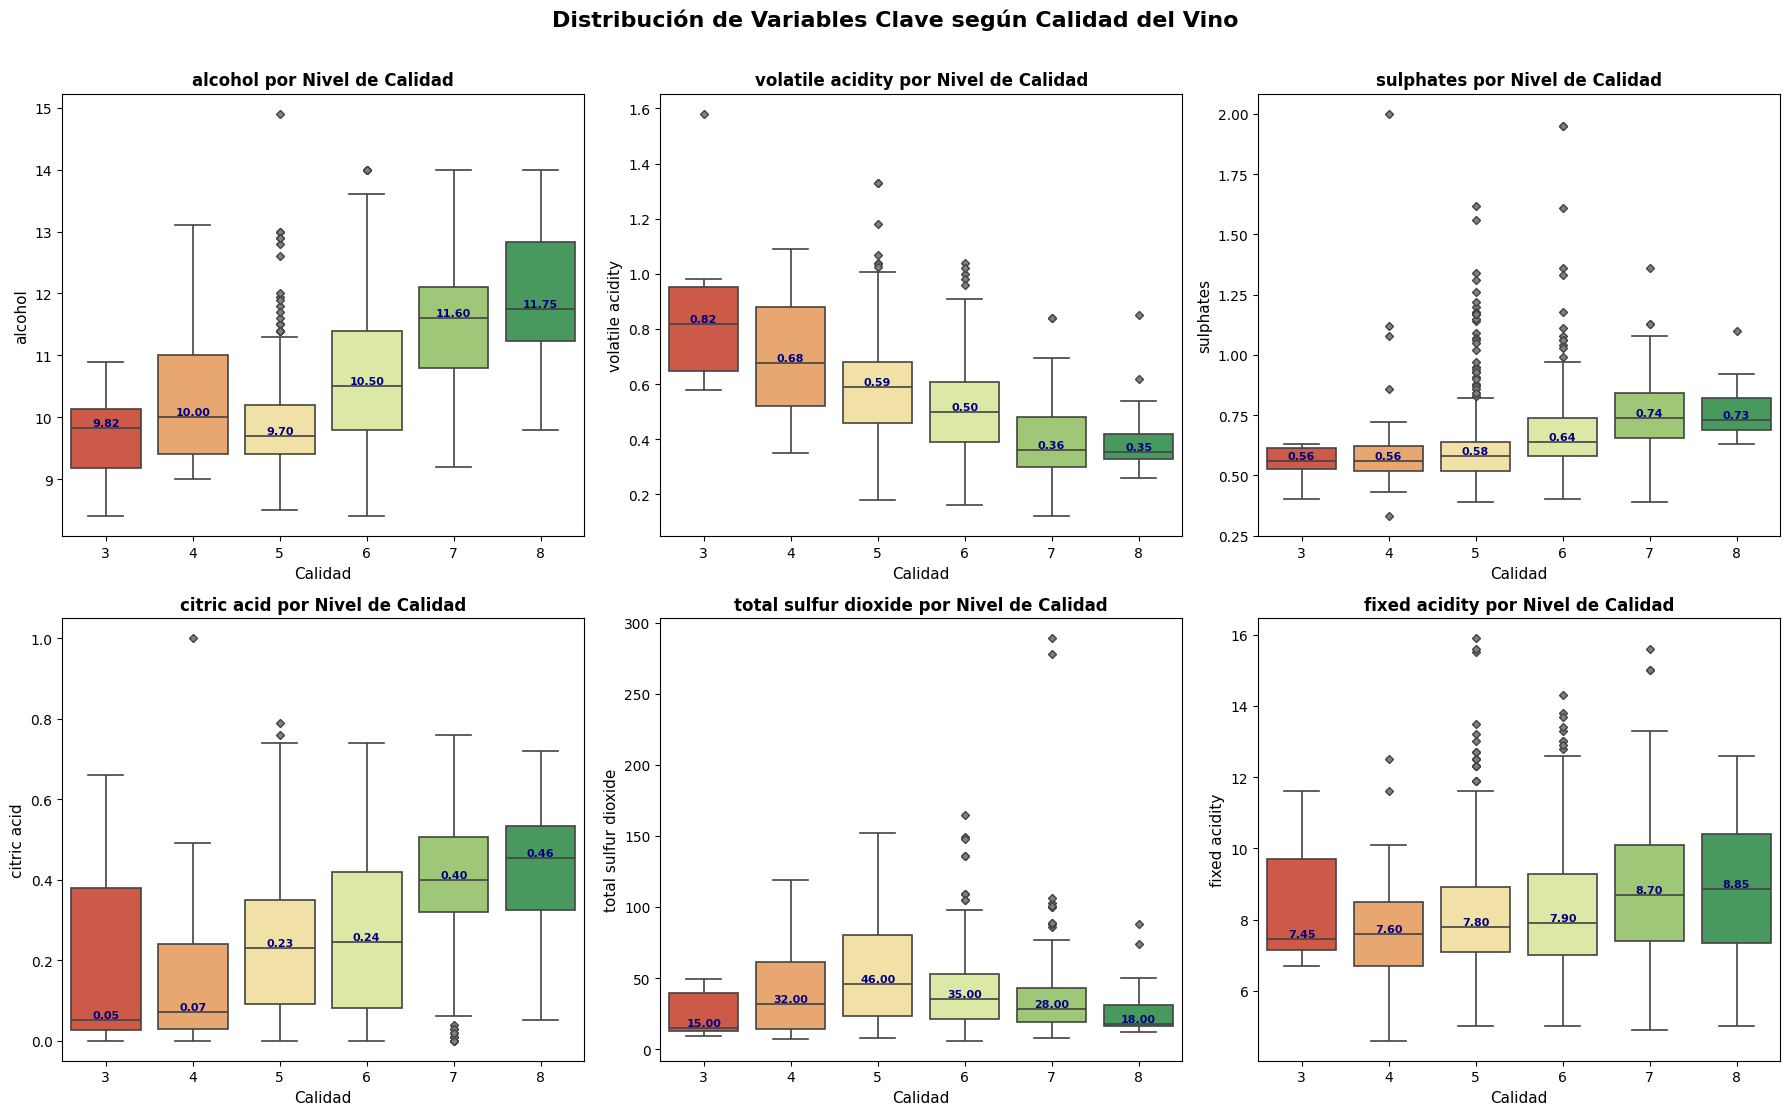

In [341]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

key_features = ['alcohol', 'volatile acidity', 'sulphates',
                'citric acid', 'total sulfur dioxide', 'fixed acidity']

palette = sns.color_palette("RdYlGn", n_colors=len(df['quality'].unique()))

for idx, feat in enumerate(key_features):
    ax = axes[idx // 3][idx % 3]
    order = sorted(df['quality'].unique())
    sns.boxplot(x='quality', y=feat, data=df, order=order,
                palette=palette, ax=ax, linewidth=1.2,
                flierprops=dict(marker='D', markerfacecolor='gray', markersize=4))
    ax.set_xlabel('Calidad', fontsize=11)
    ax.set_ylabel(feat, fontsize=11)
    ax.set_title(f'{feat} por Nivel de Calidad', fontsize=12, fontweight='bold')

    # Añadir mediana como texto
    medians = df.groupby('quality')[feat].median()
    for tick, qual in enumerate(order):
        ax.text(tick, medians[qual], f'{medians[qual]:.2f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold', color='navy')

fig.suptitle('Distribución de Variables Clave según Calidad del Vino',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()

plt.show()

# **2. Preprocesamiento de Datos:**

In [342]:
# Asignacion de variable Objetivo
X = df.drop('quality', axis=1)

y = df['quality']

# Escalamiento
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Division
X_train, X_test, y_train, y_test = train_test_split(  X_scaled, y, test_size=0.20, random_state=42, stratify=y)


## **Entrenamiento**

In [343]:
print('='*60)
print('Entrenando KNN')
print('='*60)

parametros_knn = {
    'n_neighbors':[3,5,7,9,11]
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    parametros_knn,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
tiempo= time.time()
grid_knn.fit(X_train,y_train)
tiempo_knn = time.time()-tiempo

knn = grid_knn.best_estimator_


print('Arbol optimo:', knn.n_neighbors)
print('Mejor score:', knn.score(X_test,y_test))
print('Tiempo Proceso :'+ str(tiempo_knn))

Entrenando KNN
Arbol optimo: 3
Mejor score: 0.6157205240174672
Tiempo Proceso :0.3683750629425049


In [344]:
# Entrenando Regresion Logistic

print('='*60)
print('Entrenando Regresion Logistic')
print('='*60)

param_lr = {
    'C':[0.01,0.1,1,10,100]
}

grid_lr = GridSearchCV(
    LogisticRegression(
        max_iter=5000
    ),
    param_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
tiempo= time.time()

grid_lr.fit(X_train,y_train)

tiempo_lr = time.time()-tiempo

lr = grid_lr.best_estimator_

print('Ciclo optimo:', lr.max_iter)
print('Mejor score:', lr.score(X_test,y_test))
print('Tiempo Proceso :'+ str(tiempo_lr))

Entrenando Regresion Logistic
Ciclo optimo: 5000
Mejor score: 0.6375545851528385
Tiempo Proceso :2.519702434539795


In [345]:
# Entrenando Random Forest

print('='*60)
print('Entrenando Random Forest')
print('='*60)

param_rf = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,15,None]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(
        random_state=42
    ),
    param_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
tiempo= time.time()

grid_rf.fit(X_train,y_train)

tiempo_rf = time.time()-tiempo

rf = grid_rf.best_estimator_

print('Arbol optimo:', rf.n_estimators)
print('Mejor score:', rf.score(X_test,y_test))
print('Tiempo Proceso :'+ str(tiempo_rf))


Entrenando Random Forest
Arbol optimo: 100
Mejor score: 0.6768558951965066
Tiempo Proceso :45.689117193222046


## **Evaluacion**

In [346]:
# Evaluar Modelos

modelos = {
    'KNN':knn,
    'Logistic Regression':lr,
    'Random Forest':rf
          }

resultados = []

for nombre, modelo in modelos.items():

    y_pred = modelo.predict(X_test)

    accuracy = accuracy_score(y_test,y_pred)

    precision = precision_score(
        y_test,
        y_pred ,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        y_pred ,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        y_pred ,
        average='weighted'
    )

    resultados.append([
        nombre,
        accuracy,
        precision,
        recall,
        f1
    ])

desplegar_resultados = pd.DataFrame( resultados,
      columns=[
        'Modelo',
        'Accuracy',
        'Precision',
        'Recall',
        'F1'
              ]
                             )

print('='*60)
print('Resultado de Modelos')
print('='*60)

display(desplegar_resultados)

Resultado de Modelos


,Modelo,Accuracy,Precision,Recall,F1
0,KNN,0.615721,0.610933,0.615721,0.608156
1,Logistic Regression,0.637555,0.592662,0.637555,0.584575
2,Random Forest,0.676856,0.657593,0.676856,0.647638


## **Matriz de Confusion**

Matriz de Confusion


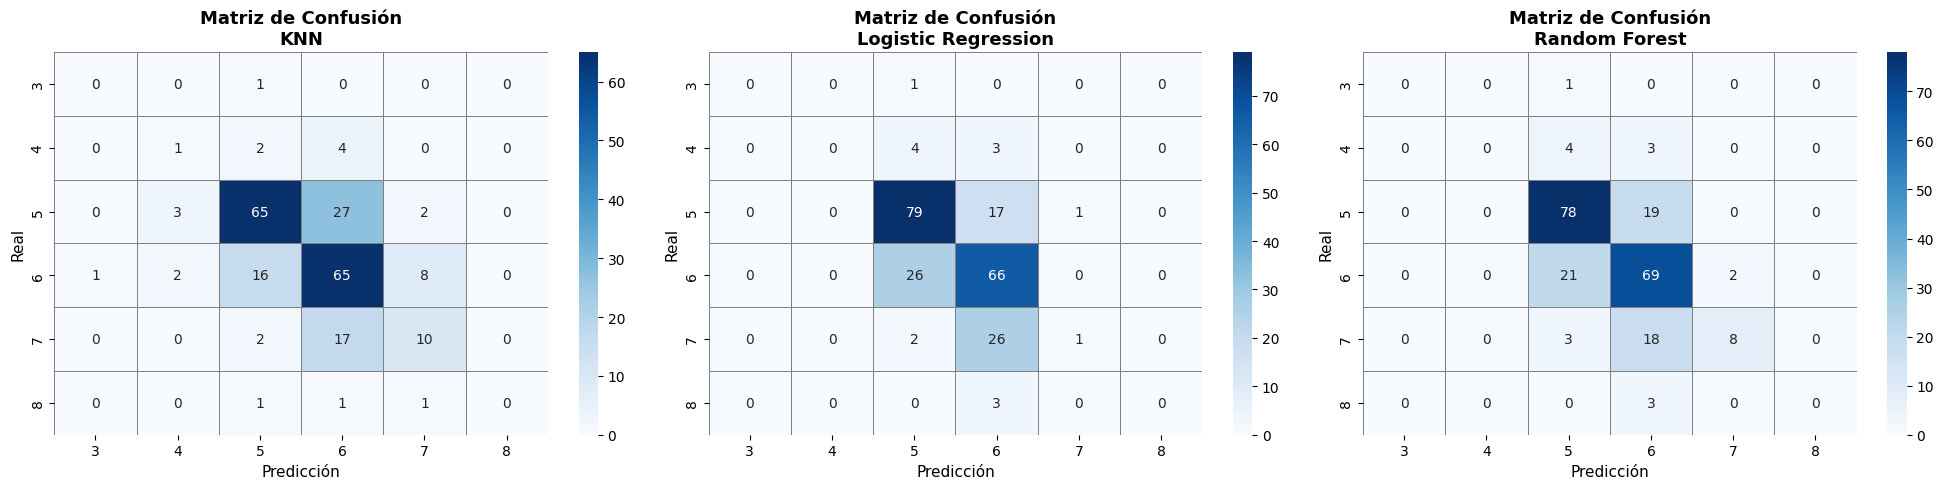

In [347]:
print('='*60)
print('Matriz de Confusion')
print('='*60)
# Matriz de Confusión para todos los modelos
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

classes = sorted(y.unique())
for idx, (name, model_obj) in enumerate(modelos.items()):
    y_pred_model = model_obj.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_model)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=classes, yticklabels=classes,
                linewidths=0.5, linecolor='gray')
    axes[idx].set_xlabel('Predicción', fontsize=11)
    axes[idx].set_ylabel('Real', fontsize=11)
    axes[idx].set_title(f'Matriz de Confusión\n{name}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

El modelo no clasfica correctamente las muestra de calidad  0,1,2,3,o 4, las predicciones estan centradas en calidades 5,6,7 y 8

In [348]:
# ============================================================
# 13. MEJOR MODELO
# ============================================================

mejor_modelo = resultados_df.sort_values( 'F1',
                  ascending=False
            ).iloc[0]['Modelo']

print('Mejor Modelo:', mejor_modelo)

if mejor_modelo == 'KNN':
    evaluar_modelo = knn

elif mejor_modelo == 'Logistic Regression':
    evaluar_modelo = lr

else:
    evaluar_modelo = rf

Mejor Modelo: Random Forest


## **Curva ROC**

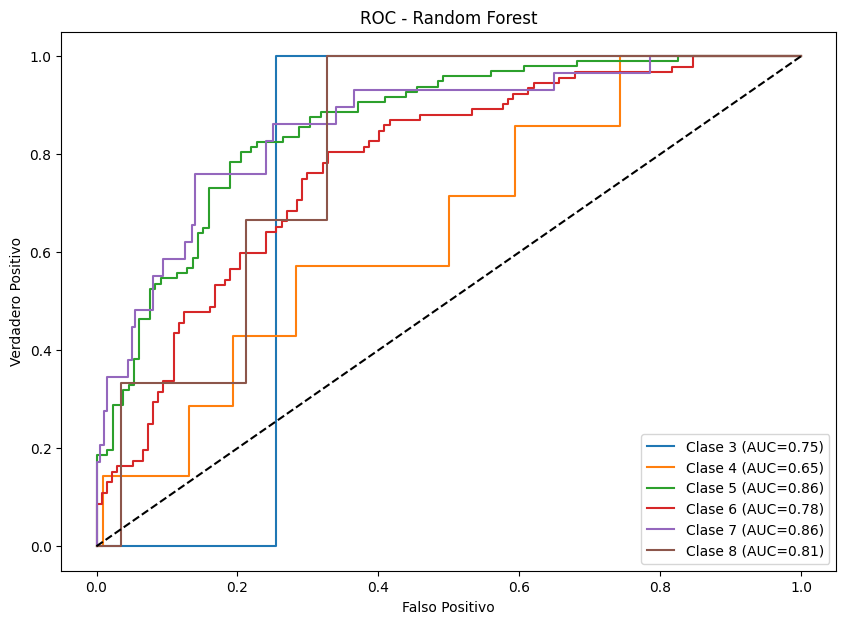

In [349]:
classes = sorted(y.unique())

y_bin = label_binarize(y_test, classes=classes)

y_score = evaluar_modelo.predict_proba(X_test)

plt.figure(figsize=(10,7))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(y_bin[:,i], y_score[:,i])

    roc_auc = auc(fpr,tpr)

    plt.plot(fpr, tpr, label=f'Clase {classes[i]} (AUC={roc_auc:.2f})')

plt.plot([0,1],[0,1],'k--')

plt.xlabel('Falso Positivo')
plt.ylabel('Verdadero Positivo')
plt.title(f'ROC - {mejor_modelo}')
plt.legend()
plt.show()

El analisis de la Curva ROC para el mejor modelo en este caso Random forest, logra tener un buen rendimiento en la clase 8 que lo que se esta bucando clasificar que son los mejores, pero tiene una mejor tien aun mejor rendimeinto para los vino de Clase Media-Buena que son las Clases  5 y 7.

# **5. Análisis y Comparación de Resultados:**

## **Comparar el rendimiento de los diferentes modelos.**

KNN estuvo por muy poco por debajo de Random Forest, el problema de este  modelo es sensible a la escala de las variables y al ruido presente en los datos, lo que puede degradar su capacidad de encontrar vecinos representativos.

Regresion Logistica , estuvo por debajo de la comptencia, no alcanza a interpretar las diferentes variables que conjugan la calidad del Vino.

Random Forest, Ofrece importancia de caracteristicas, lo que permite identificar qué variables para predecir en este caso la calidad.

## **Discutir cuál modelo ofrece el mejor rendimiento y por qué.**

El modelo Random Forest supera a los demas porque puede manejar las diferentes variables en una combinaacion de multiples arboles de desicion, esto se ajusta tambien donde la calidad del vino esta dada por diferentes combinaciones de factores de tipos quimicos.

Por otro lado en la lectura de los indices tiene todos los valores mas altos que su competencia logrando menos falsos positivos.

## **Identificar las fortalezas y debilidades de cada enfoque en este contexto.**

Random Forest, clasifica muy con muchas variables y se agregasn mas arboles al entrenamiento se ajusta a resultados existoso, pero requiere mayor tiempo de entrenamiento

Regresion Logistica no resuelve muy bien la relación lineal entre las características, es la mas rapida en los tiempos de entrenamiento

KNN requiere calcular distancias con todos los puntos de entrenamiento lo que lo hace costoso, pero es simple e intuitivo clasificando según la similitud con los vecinos más cercanos.